# Preprocesamiento y Modelado con PySpark






##  Librerías e Inicialización

In [ ]:
import time
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder,
                                 VectorAssembler, StandardScaler)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation    import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

sns.set_theme(style='whitegrid')

spark = (SparkSession.builder
         .appName('LendingClub_PySpark')
         .config('spark.driver.memory', '6g')
         .config('spark.driver.maxResultSize', '2g')
         .config('spark.sql.shuffle.partitions', '4')
         .config('spark.executor.heartbeatInterval', '60s')
         .config('spark.network.timeout', '300s')
         .getOrCreate())

spark.sparkContext.setLogLevel('WARN')
print(f' SparkSession iniciada — Spark {spark.version}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/09 20:28:21 WARN Utils: Your hostname, Sara, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/09 20:28:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 20:28:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


 SparkSession iniciada — Spark 4.1.1


##  Carga del Dataset

In [ ]:
sdf_raw = (spark.read
           .option('header', 'true')
           .option('inferSchema', 'false')
           .csv('df_clean.csv'))

print(f'Columnas: {len(sdf_raw.columns)}')
sdf_raw.show(3)

Columnas: 93


26/03/09 20:28:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+---------+-----------+---------------+----------+--------+-----------+-----+---------+------------+----------+--------------+----------+-------------------+--------+----------+--------------------+------------------+------------------+--------+----------+-----+-----------+----------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+-----------------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------------+--------------------+-------------------+--------------------------+-----------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+--------------------

---
# Parte 1: Preprocesamiento

##  Selección de Variables

In [ ]:
CANDIDATE_FEATURES = [
    'loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
    'annual_inc', 'purpose', 'home_ownership', 'dti',
    'term', 'sub_grade', 'verification_status',
    'open_acc', 'pub_rec', 'revol_util', 'mort_acc',
    'installment', 'default'
]

available = [c for c in CANDIDATE_FEATURES if c in sdf_raw.columns]
sdf = sdf_raw.select(available)


NUMERIC_CANDIDATES = [
    'loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
    'annual_inc', 'dti', 'open_acc', 'pub_rec',
    'revol_util', 'mort_acc', 'installment'
]
for col in NUMERIC_CANDIDATES:
    if col in sdf.columns:
        sdf = sdf.withColumn(col, F.expr(f"try_cast({col} as double)"))

sdf = sdf.withColumn("default", F.expr("try_cast(default as float)").cast("int"))
sdf = sdf.dropna()
sdf = sdf.filter(F.col("default").isin([0, 1]))


CAT_COLS = [f.name for f in sdf.schema.fields
            if isinstance(f.dataType, StringType) and f.name != 'default']
NUM_COLS = [f.name for f in sdf.schema.fields
            if not isinstance(f.dataType, StringType) and f.name != 'default']


sdf = sdf.limit(500000)
sdf = sdf.repartition(4)
sdf.cache()

print(f'Registros disponibles: {sdf.count():,}')
print(f'Numéricas  ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Categóricas({len(CAT_COLS)}): {CAT_COLS}')
sdf.show(3)

Registros disponibles: 500,000
Numéricas  (11): ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_util', 'mort_acc', 'installment']
Categóricas(5): ['purpose', 'home_ownership', 'term', 'sub_grade', 'verification_status']
+---------+--------+---------------+----------+----------+------------------+--------------+-----+----------+---------+-------------------+--------+-------+----------+--------+-----------+-------+
|loan_amnt|int_rate|fico_range_high|emp_length|annual_inc|           purpose|home_ownership|  dti|      term|sub_grade|verification_status|open_acc|pub_rec|revol_util|mort_acc|installment|default|
+---------+--------+---------------+----------+----------+------------------+--------------+-----+----------+---------+-------------------+--------+-------+----------+--------+-----------+-------+
|   6000.0|    8.18|          704.0|      10.0|   35000.0|debt_consolidation|      MORTGAGE|28.88| 36 months|       B1|       N

##  División Train/Test 



In [ ]:
sdf_0 = sdf.filter(F.col('default') == 0)
sdf_1 = sdf.filter(F.col('default') == 1)

train_0, test_0 = sdf_0.randomSplit([0.8, 0.2], seed=42)
train_1, test_1 = sdf_1.randomSplit([0.8, 0.2], seed=42)

train_sdf = train_0.union(train_1)
test_sdf  = test_0.union(test_1)

n_train = train_sdf.count()
n_test  = test_sdf.count()

print(f'Train: {n_train:,} filas')
print(f'Test : {n_test:,} filas')
print()
print('Distribución de clases — Train:')
train_sdf.groupBy('default').count().orderBy('default').show()
print('Distribución de clases — Test:')
test_sdf.groupBy('default').count().orderBy('default').show()

Train: 400,194 filas
Test : 99,806 filas

Distribución de clases — Train:
+-------+------+
|default| count|
+-------+------+
|      0|315772|
|      1| 84422|
+-------+------+

Distribución de clases — Test:
+-------+-----+
|default|count|
+-------+-----+
|      0|78911|
|      1|20895|
+-------+-----+



##  Pipeline de Preprocesamiento

###  StringIndexer categóricas a índice numérico

In [ ]:
indexers = [
    StringIndexer(inputCol=col, outputCol=col + '_idx', handleInvalid='keep')
    for col in CAT_COLS
]
print(f'StringIndexers: {[col + "_idx" for col in CAT_COLS]}')

StringIndexers: ['purpose_idx', 'home_ownership_idx', 'term_idx', 'sub_grade_idx', 'verification_status_idx']


###  OneHotEncoder 

In [ ]:
encoders = [
    OneHotEncoder(inputCol=col + '_idx', outputCol=col + '_ohe')
    for col in CAT_COLS
]
print(f'OneHotEncoders: {[col + "_ohe" for col in CAT_COLS]}')

OneHotEncoders: ['purpose_ohe', 'home_ownership_ohe', 'term_ohe', 'sub_grade_ohe', 'verification_status_ohe']


###  VectorAssembler + StandardScaler

In [ ]:
assembler_inputs = NUM_COLS + [col + '_ohe' for col in CAT_COLS]

assembler = VectorAssembler(
    inputCols  = assembler_inputs,
    outputCol  = 'features_raw',
    handleInvalid = 'skip'
)

scaler = StandardScaler(
    inputCol  = 'features_raw',
    outputCol = 'features',
    withMean  = True,
    withStd   = True
)

prep_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])

print('Pipeline de preprocesamiento:')
for i, stage in enumerate(prep_pipeline.getStages()):
    print(f'  Stage {i+1}: {type(stage).__name__}')

Pipeline de preprocesamiento:
  Stage 1: StringIndexer
  Stage 2: StringIndexer
  Stage 3: StringIndexer
  Stage 4: StringIndexer
  Stage 5: StringIndexer
  Stage 6: OneHotEncoder
  Stage 7: OneHotEncoder
  Stage 8: OneHotEncoder
  Stage 9: OneHotEncoder
  Stage 10: OneHotEncoder
  Stage 11: VectorAssembler
  Stage 12: StandardScaler


###  Ajustar y transformar

In [ ]:
print('Ajustando pipeline de preprocesamiento...')
t0 = time.time()

prep_model = prep_pipeline.fit(train_sdf)
train_prep = prep_model.transform(train_sdf)
test_prep  = prep_model.transform(test_sdf)

print(f' Pipeline ajustado en {time.time()-t0:.2f} s')
print()
train_prep.select('default', 'features').show(3, truncate=70)

Ajustando pipeline de preprocesamiento...


 Pipeline ajustado en 2.97 s

+-------+----------------------------------------------------------------------+
|default|                                                              features|
+-------+----------------------------------------------------------------------+
|      0|[-1.555242391564838,-1.5749915126466405,-0.15645785722965613,-1.652...|
|      0|[-1.555242391564838,-1.5749915126466405,2.383210666435941,1.1219786...|
|      0|[-1.555242391564838,-1.5749915126466405,3.1768570800814406,1.121978...|
+-------+----------------------------------------------------------------------+
only showing top 3 rows


---
# Parte 2: Modelado con PySpark

##  Búsqueda Manual de Hiperparámetros



In [ ]:
n_estimators_list = [10, 50, 100]
max_depth_list    = [5, 10]

combinations = list(itertools.product(n_estimators_list, max_depth_list))

evaluator_auc = BinaryClassificationEvaluator(
    labelCol         = 'default',
    rawPredictionCol = 'rawPrediction',
    metricName       = 'areaUnderROC'
)

results = []

print(f'Combinaciones a probar: {len(combinations)}')
print(f'{"n_est":>6} {"max_d":>6} {"ROC_AUC":>10} {"Tiempo(s)":>10}')
print('-' * 38)

for n_est, max_d in combinations:
    rf = RandomForestClassifier(
        labelCol        = 'default',
        featuresCol     = 'features',
        numTrees        = n_est,
        maxDepth        = max_d,
        maxBins         = 32,
        subsamplingRate = 0.8,
        seed            = 42
    )
    t_start = time.time()
    model   = rf.fit(train_prep)
    t_train = time.time() - t_start

    preds = model.transform(test_prep)
    auc   = evaluator_auc.evaluate(preds)

    results.append({
        'n_estimators' : n_est,
        'max_depth'    : max_d,
        'roc_auc'      : round(auc, 4),
        'train_time_s' : round(t_train, 2),
        'model'        : model,
        'predictions'  : preds
    })
    print(f'{n_est:>6} {max_d:>6} {auc:>10.4f} {t_train:>10.2f}')

Combinaciones a probar: 6
 n_est  max_d    ROC_AUC  Tiempo(s)
--------------------------------------


    10      5     0.6985       6.46


26/03/09 20:28:43 WARN DAGScheduler: Broadcasting large task binary with size 1228.6 KiB


    10     10     0.7188       3.64


    50      5     0.7077       4.00


26/03/09 20:28:52 WARN DAGScheduler: Broadcasting large task binary with size 1073.6 KiB
26/03/09 20:28:53 WARN DAGScheduler: Broadcasting large task binary with size 1857.9 KiB
26/03/09 20:28:54 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/03/09 20:28:55 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/09 20:28:56 WARN DAGScheduler: Broadcasting large task binary with size 1153.0 KiB
26/03/09 20:28:57 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


    50     10     0.7219       8.68


   100      5     0.7103       5.92


26/03/09 20:29:12 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/03/09 20:29:13 WARN DAGScheduler: Broadcasting large task binary with size 1976.0 KiB
26/03/09 20:29:15 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/03/09 20:29:17 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
26/03/09 20:29:19 WARN DAGScheduler: Broadcasting large task binary with size 1466.6 KiB
26/03/09 20:29:20 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/03/09 20:29:23 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/03/09 20:29:24 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB


   100     10     0.7221      20.13


###  Heatmap de resultados

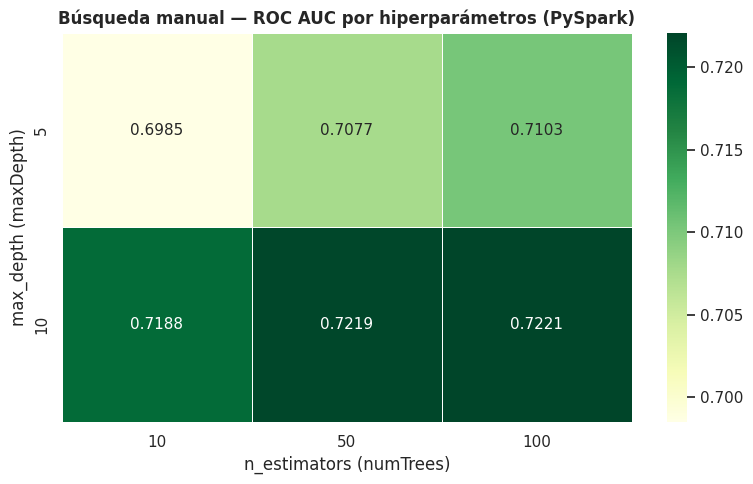

n_estimators     10      50      100
max_depth                           
5             0.6985  0.7077  0.7103
10            0.7188  0.7219  0.7221


In [ ]:
df_results = pd.DataFrame([{k: v for k, v in r.items()
                              if k not in ('model', 'predictions')}
                             for r in results])

pivot = df_results.pivot(index='max_depth', columns='n_estimators', values='roc_auc')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Búsqueda manual — ROC AUC por hiperparámetros (PySpark)', fontweight='bold')
ax.set_xlabel('n_estimators (numTrees)')
ax.set_ylabel('max_depth (maxDepth)')
plt.tight_layout()
plt.savefig('spark_01_gridsearch_heatmap.png', bbox_inches='tight')
plt.show()

print(pivot.to_string())

##  Selección del Mejor Modelo

In [ ]:
best_result = max(results, key=lambda r: r['roc_auc'])
best_model  = best_result['model']
best_preds  = best_result['predictions']

print(f'Mejores hiperparámetros:')
print(f'  n_estimators (numTrees): {best_result["n_estimators"]}')
print(f'  max_depth               : {best_result["max_depth"]}')
print(f'  ROC AUC (test)          : {best_result["roc_auc"]}')
print(f'  Tiempo entrenamiento    : {best_result["train_time_s"]} s')

Mejores hiperparámetros:
  n_estimators (numTrees): 100
  max_depth               : 10
  ROC AUC (test)          : 0.7221
  Tiempo entrenamiento    : 20.13 s


##  Predicción y Tiempo

In [ ]:
best_rf = RandomForestClassifier(
    labelCol        = 'default',
    featuresCol     = 'features',
    numTrees        = best_result['n_estimators'],
    maxDepth        = best_result['max_depth'],
    maxBins         = 32,
    subsamplingRate = 0.8,
    seed            = 42
)

t_train_start = time.time()
final_model   = best_rf.fit(train_prep)
t_train_final = time.time() - t_train_start

t_pred_start = time.time()
final_preds  = final_model.transform(test_prep)
final_preds.count()
t_pred_final = time.time() - t_pred_start

print(f' Tiempo entrenamiento: {t_train_final:.2f} s')
print(f'  Tiempo predicción   : {t_pred_final:.4f} s')

26/03/09 20:29:30 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/03/09 20:29:32 WARN DAGScheduler: Broadcasting large task binary with size 1976.0 KiB
26/03/09 20:29:33 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/03/09 20:29:35 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
26/03/09 20:29:38 WARN DAGScheduler: Broadcasting large task binary with size 1466.6 KiB
26/03/09 20:29:38 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/03/09 20:29:42 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


 Tiempo entrenamiento: 17.84 s
  Tiempo predicción   : 0.3362 s


##  Métricas de Evaluación

In [ ]:
auc = evaluator_auc.evaluate(final_preds)


mc_eval = MulticlassClassificationEvaluator(labelCol='default', predictionCol='prediction')

acc  = mc_eval.evaluate(final_preds, {mc_eval.metricName: 'accuracy'})
prec = mc_eval.evaluate(final_preds, {mc_eval.metricName: 'weightedPrecision'})
rec  = mc_eval.evaluate(final_preds, {mc_eval.metricName: 'weightedRecall'})
f1   = mc_eval.evaluate(final_preds, {mc_eval.metricName: 'f1'})

print('=' * 42)
print('    MÉTRICAS — RandomForest (PySpark)')
print('=' * 42)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-score  : {f1:.4f}')
print(f'  ROC AUC   : {auc:.4f}')
print('-' * 42)
print(f'  Tiempo entrenamiento: {t_train_final:.2f} s')
print(f'  Tiempo predicción   : {t_pred_final:.4f} s')
print('=' * 42)

26/03/09 20:29:43 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/09 20:29:44 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/09 20:29:47 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/09 20:29:48 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/09 20:29:48 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB


    MÉTRICAS — RandomForest (PySpark)
  Accuracy  : 0.7943
  Precision : 0.7571
  Recall    : 0.7943
  F1-score  : 0.7187
  ROC AUC   : 0.7221
------------------------------------------
  Tiempo entrenamiento: 17.84 s
  Tiempo predicción   : 0.3362 s


##  Matriz de Confusión

26/03/09 20:29:49 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/09 20:29:50 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB


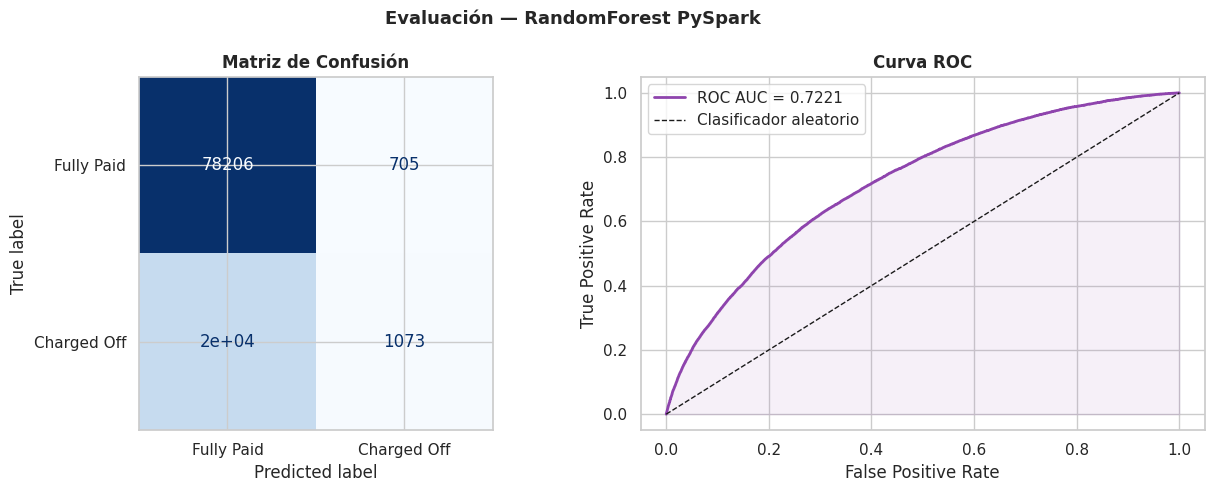

In [ ]:
# Convertir a Pandas para visualizar
preds_pd = final_preds.select('default', 'prediction').toPandas()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

cm = confusion_matrix(preds_pd['default'], preds_pd['prediction'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Fully Paid', 'Charged Off'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión', fontweight='bold')

# Curva ROC — usar probabilidad de clase positiva
proba_pd = final_preds.select('default', 'probability').toPandas()
proba_pd['prob_1'] = proba_pd['probability'].apply(lambda v: float(v[1]))

fpr, tpr, _ = roc_curve(proba_pd['default'], proba_pd['prob_1'])
axes[1].plot(fpr, tpr, color='#8e44ad', lw=2, label=f'ROC AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#8e44ad')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

plt.suptitle('Evaluación — RandomForest PySpark', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spark_02_evaluation.png', bbox_inches='tight')
plt.show()

##  Importancia de Variables

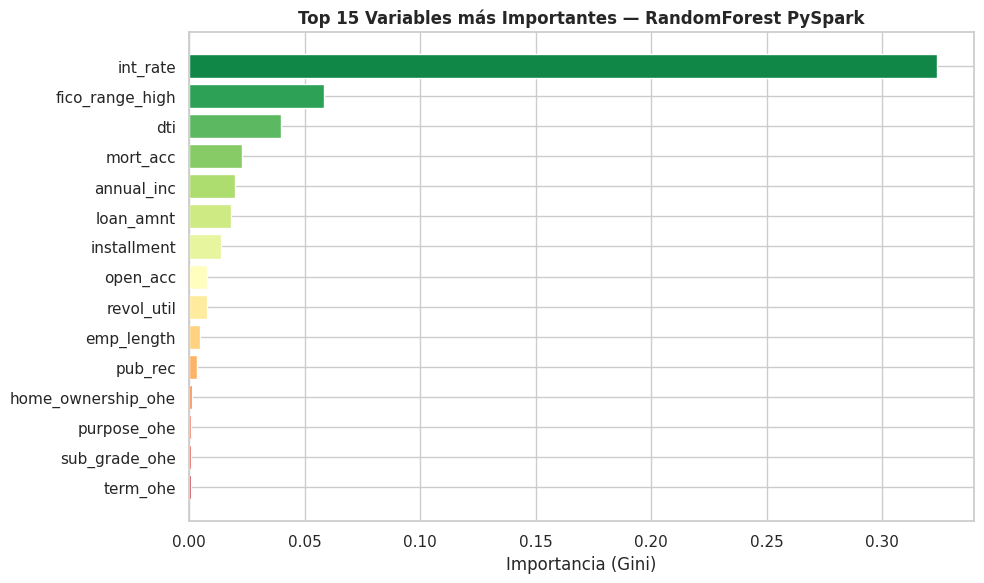

In [ ]:
feature_names = NUM_COLS + [col + '_ohe' for col in CAT_COLS]
importances   = final_model.featureImportances.toArray()

n = min(len(feature_names), len(importances))
imp_series = pd.Series(importances[:n], index=feature_names[:n]).sort_values(ascending=False)

top15 = imp_series.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('RdYlGn_r', len(top15))
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 15 Variables más Importantes — RandomForest PySpark', fontweight='bold')
plt.tight_layout()
plt.savefig('spark_03_feature_importance.png', bbox_inches='tight')
plt.show()

##  Resumen Final

In [ ]:
metrics_spark = {
    'Modelo'        : 'RandomForest (PySpark)',
    'n_estimators'  : best_result['n_estimators'],
    'max_depth'     : best_result['max_depth'],
    'Accuracy'      : round(acc,  4),
    'Precision'     : round(prec, 4),
    'Recall'        : round(rec,  4),
    'F1-score'      : round(f1,   4),
    'ROC AUC'       : round(auc,  4),
    'Tiempo_train_s': round(t_train_final, 2),
    'Tiempo_pred_s' : round(t_pred_final,  4)
}

pd.DataFrame([metrics_spark])

,Modelo,n_estimators,max_depth,Accuracy,Precision,Recall,F1-score,ROC AUC,Tiempo_train_s,Tiempo_pred_s
0,RandomForest (PySpark),100,10,0.7943,0.7571,0.7943,0.7187,0.7221,17.84,0.3362


In [ ]:
import json
with open('metrics_spark.json', 'w') as f:
    json.dump(metrics_spark, f, indent=2)

spark.stop()
print(' SparkSession cerrada')

 SparkSession cerrada
